# LPJ-GUESS FPC vs LAI: range shift vs densification

Standalone analysis (no surfdata edit). Answers, from the FPC and LAI files:
1. how FPC relates to LAI (Beer law; grass vs tree crown factor);
2. how much of each PFT's change is **colonization** (range shift) vs
   **densification** (in-place leaf-area gain);
3. the larch FPC under-read, for the methods caveat.

Colonization = PFT absent historically (FPC<eps) but present in future.
Densification = PFT present in both, LAI rising with little FPC change
(FPC saturates, so it hides most of the leaf-area gain).


In [3]:
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "STIXGeneral", "mathtext.fontset": "stix",
                     "axes.titlesize": 14, "font.size": 12})

DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS")
FPC_HIST = DATA / "fpc1971to2000.txt"
FPC_FUT  = DATA / "GFDL-ESM4_SSP585_fpc2071to2100.txt"
LAI_HIST = DATA / "lai1971to2000.txt"
LAI_FUT  = DATA / "GFDL-ESM4_SPP585_lai2071to2100.txt"   # note SPP typo in filename

LPJ_NATURAL = ["BNE","BINE","BNS","TeNE","TeBE","IBS","TeBS","C3G",
               "HSE","HSS","LSE","LSS","GRT","EPDS","SPDS","CLM"]
K = 0.5                      # Lambert-Beer extinction (lambertbeer = exp(-0.5*lai) from LPJ-GUESS code)
EPS = 0.02                   # presence threshold in FPC

def load(path, names=LPJ_NATURAL):
    df = pd.read_csv(path, sep=r"\s+").set_index(["Lat", "Lon"])[names]
    da = xr.DataArray(df.values, coords={"lonlat": df.index, "natpft": names},
                      dims=["lonlat", "natpft"]).unstack("lonlat")
    return da.rename({"Lat": "lat", "Lon": "lon"}).transpose("natpft", "lat", "lon")

Fh, Ff = load(FPC_HIST), load(FPC_FUT)
Lh, Lf = load(LAI_HIST), load(LAI_FUT)

def _circle(ax):
    t = np.linspace(0, 2*np.pi, 100)
    ax.set_boundary(mpath.Path(np.vstack([np.sin(t), np.cos(t)]).T*0.5 + [0.5, 0.5]),
                    transform=ax.transAxes)
def bmap(da, title="", ax=None, **kw):
    if ax is None:
        plt.figure(figsize=(5, 5)); ax = plt.axes(projection=ccrs.Orthographic(0, 90))
    ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree()); _circle(ax)
    da.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), add_colorbar=False, **kw)
    ax.coastlines(linewidth=0.5); ax.gridlines(alpha=0.3); ax.set_title(title)
    return ax


## 1 · FPC-LAI relationship (Beer law): grass k~0.5, trees appear lower
From growth.cpp: grass `fpc = 1-exp(-0.5*lai)`; tree
`fpc = crownarea*densindiv*(1-exp(-0.5*lai_ind))` — the crown footprint makes
a one-factor fit to trees look like k<0.5. Reported LAI behaves as within-crown
`lai_ind`.


In [4]:
def implied_k(p):
    f, l = Fh.sel(natpft=p).values.ravel(), Lh.sel(natpft=p).values.ravel()
    m = (f > EPS) & (f < 0.8) & (l > 0.05) & np.isfinite(f) & np.isfinite(l)
    return np.median(-np.log(np.clip(1-f[m], 1e-6, 1))/l[m]) if m.sum() > 20 else np.nan

print("implied one-factor k  (grass ~0.5; trees lower = crown footprint):")
for p in ["GRT","C3G","BNE","BNS","IBS"]:
    print(f"  {p:5s}: {implied_k(p):.2f}")


implied one-factor k  (grass ~0.5; trees lower = crown footprint):
  GRT  : 0.49
  C3G  : 0.35
  BNE  : 0.28
  BNS  : 0.37
  IBS  : 0.27


## 2 · Colonization vs persist, per CLM-target PFT group


In [5]:
groups = {"BoNET (BNE,BINE)": ["BNE","BINE"], "BoNDT (BNS)": ["BNS"],
          "BoBDT (IBS)": ["IBS"], "BoBDS shrubs": ["HSE","HSS","LSE","LSS","EPDS","SPDS"],
          "aC3 (C3G,GRT)": ["C3G","GRT"]}
rows = []
for nm, cols in groups.items():
    fh = Fh.sel(natpft=cols).sum("natpft"); ff = Ff.sel(natpft=cols).sum("natpft")
    lh = Lh.sel(natpft=cols).sum("natpft"); lf = Lf.sel(natpft=cols).sum("natpft")
    dF = (ff - fh); dL = (lf - lh)
    colon = (fh < EPS) & (ff >= EPS); persist = (fh >= EPS) & (ff >= EPS)
    pos = dF > 0; tot = float(dF.where(pos).sum())
    pc = float(dF.where(pos & colon).sum())/tot*100 if tot > 0 else np.nan
    rows.append([nm, float(dF.sum()), pc,
                 float(dL.where(persist).mean()), float(dF.where(persist).mean())])
tab = pd.DataFrame(rows, columns=["group","sum dFPC","% colonization",
                                  "persist mean dLAI","persist mean dFPC"])
print(tab.to_string(index=False, float_format=lambda x: f"{x:+.2f}"))


           group  sum dFPC  % colonization  persist mean dLAI  persist mean dFPC
BoNET (BNE,BINE)   +766.30          +55.93              +0.26              -0.01
     BoNDT (BNS)  +1235.35          +18.43              +1.65              +0.34
     BoBDT (IBS)  +1184.30          +49.67              +0.92              +0.18
    BoBDS shrubs   +236.84          +19.27              +0.28              +0.04
   aC3 (C3G,GRT)  -1653.87          +34.33              -0.35              -0.13


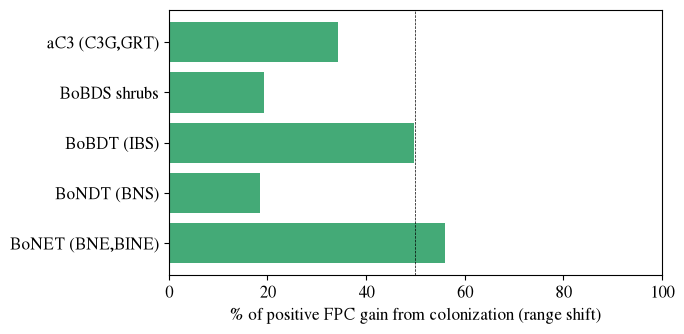

In [6]:
# bar chart: colonization share per group
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(tab["group"], tab["% colonization"], color="#4a7")
ax.set_xlabel("% of positive FPC gain from colonization (range shift)")
ax.axvline(50, color="k", lw=0.5, ls="--"); ax.set_xlim(0, 100)
plt.tight_layout()


## 3 · Where is the change? colonization vs persist cells (maps)
Green = colonization (new footprint); orange = persist-cell densification.


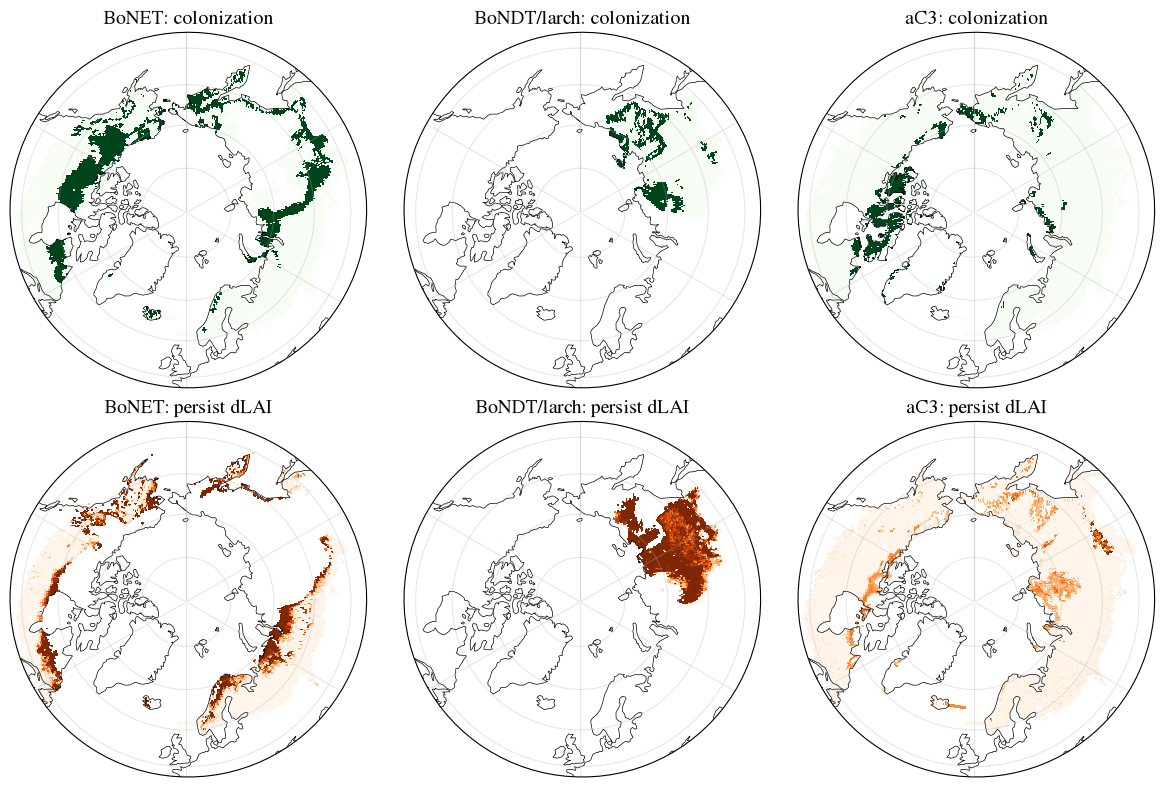

In [7]:
show = {"BoNET": ["BNE","BINE"], "BoNDT/larch": ["BNS"], "aC3": ["C3G","GRT"]}
fig, axes = plt.subplots(2, len(show), figsize=(4*len(show), 8),
                         subplot_kw={"projection": ccrs.Orthographic(0, 90)})
for k, (nm, cols) in enumerate(show.items()):
    fh = Fh.sel(natpft=cols).sum("natpft"); ff = Ff.sel(natpft=cols).sum("natpft")
    lh = Lh.sel(natpft=cols).sum("natpft"); lf = Lf.sel(natpft=cols).sum("natpft")
    colon = ((fh < EPS) & (ff >= EPS)).where(ff > 0)
    ddens = (lf - lh).where((fh >= EPS) & (ff >= EPS))
    bmap(colon, f"{nm}: colonization", axes[0, k], cmap="Greens", vmin=0, vmax=1)
    bmap(ddens, f"{nm}: persist dLAI", axes[1, k], cmap="Oranges", vmin=0, vmax=1.5)
plt.tight_layout()


## 4 · Larch FPC under-read (methods caveat)
Opacity = 1 - exp(-0.5*LAI) is the fraction of the crown footprint FPC captures.
Sparse deciduous larch has low opacity -> FPC under-reads its area. As it
densifies, opacity rises (the under-read partly self-corrects).


In [8]:
for p, nm in [("BNE","evergreen"), ("BNS","larch"), ("IBS","broadleaf")]:
    f, l = Fh.sel(natpft=p), Lh.sel(natpft=p)
    m = (f > EPS) & (l > 0.05)
    op = (1 - np.exp(-K*l)).where(m)
    print(f"{p:4s} ({nm:9s}): median LAI {float(l.where(m).median()):.2f}  "
          f"opacity {float(op.median()):.2f}  (FPC = this frac of footprint)")

# larch: does the under-read shrink into the future (persist cells)?
p = "BNS"; m = (Fh.sel(natpft=p) > EPS) & (Ff.sel(natpft=p) > EPS)
oph = (1 - np.exp(-K*Lh.sel(natpft=p))).where(m)
opf = (1 - np.exp(-K*Lf.sel(natpft=p))).where(m)
print(f"\nlarch persist opacity: hist {float(oph.median()):.2f} -> future {float(opf.median()):.2f}")
print("(rising opacity = canopy filling in; part of the persist dFPC is footprint fill-in, not new area)")


BNE  (evergreen): median LAI 1.46  opacity 0.52  (FPC = this frac of footprint)
BNS  (larch    ): median LAI 0.81  opacity 0.33  (FPC = this frac of footprint)
IBS  (broadleaf): median LAI 0.47  opacity 0.21  (FPC = this frac of footprint)

larch persist opacity: hist 0.38 -> future 0.75
(rising opacity = canopy filling in; part of the persist dFPC is footprint fill-in, not new area)
